Hing_RoBERTa Train

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm   # ← This is the key fix for Kaggle!

# ==========================================
# 1. CONFIGURATION
# ==========================================
TRAIN_PATH = '/kaggle/input/nlp-dataset/train.csv'
VAL_PATH   = '/kaggle/input/nlp-dataset/validation.csv'

MODEL_NAME = 'l3cube-pune/hing-roberta'        # Great for Hinglish
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Unique model save name
SAVE_DIR = '/kaggle/working/hing-roberta-sarcasm-detector-v2'

print(f"Using device: {DEVICE}")
print(f"Model will be saved as: {SAVE_DIR}")

# ==========================================
# 2. DATA LOADING
# ==========================================
print("Loading train and validation CSVs...")
df_train = pd.read_csv(TRAIN_PATH)
df_val   = pd.read_csv(VAL_PATH)

# Ensure column names are correct (adjust if different)
# Expected: 'Tweet' (text) and 'Label' (Sarcastic/Non-Sarcastic or 0/1)
print("Train columns:", df_train.columns.tolist())
print("Val columns:  ", df_val.columns.tolist())

# Encode labels
le = LabelEncoder()
# Fit on combined labels to ensure same mapping
all_labels = pd.concat([df_train['Label'], df_val['Label']], axis=0)
le.fit(all_labels)

df_train['label_enc'] = le.transform(df_train['Label'])
df_val['label_enc']   = le.transform(df_val['Label'])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ==========================================
# 3. DATASET CLASS
# ==========================================
class SarcasmDataset(Dataset):
    def __init__(self, tweets, labels, tokenizer, max_len):
        self.tweets = tweets
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.tweets)

    def __getitem__(self, idx):
        tweet = str(self.tweets[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ==========================================
# 4. DATA LOADERS
# ==========================================
def create_data_loader(df, tokenizer, max_len, batch_size):
    dataset = SarcasmDataset(
        tweets=df['Tweet'].to_numpy(),
        labels=df['label_enc'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

train_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_loader   = create_data_loader(df_val,   tokenizer, MAX_LEN, BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ==========================================
# 5. MODEL SETUP
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# 6. TRAINING & EVALUATION FUNCTIONS (FIXED FOR KAGGLE)
# ==========================================


def train_epoch(model, loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # One clean progress bar — no new lines per step
    pbar = tqdm(total=len(loader), desc=f"Training Epoch", leave=True)
    
    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        _, preds = torch.max(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

        # Update the SAME bar smoothly
        pbar.update(1)
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc' : f'{correct/total:.4f}'
        })

    pbar.close()
    return correct / total, total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(total=len(loader), desc="Evaluating", leave=True)

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc' : f'{correct/total:.4f}'
            })

    pbar.close()
    return correct / total, total_loss / len(loader), all_preds, all_labels


# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, DEVICE, scheduler)
    print(f"→ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    val_acc, val_loss, _, _ = evaluate(model, val_loader, DEVICE)
    print(f"→ Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

# ==========================================
# 8. FINAL EVALUATION & REPORT
# ==========================================
print("\nGenerating final report on validation set...")
val_acc, val_loss, y_pred, y_true = evaluate(model, val_loader, DEVICE)

print("\n" + classification_report(y_true, y_pred, target_names=le.classes_))
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'HingRoBERTa Sarcasm Detector (Val Acc: {val_acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ==========================================
# 9. SAVE MODEL WITH UNIQUE NAME
# ==========================================
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"\nModel and tokenizer successfully saved to:")
print(f"→ {SAVE_DIR}")

print("\nTo load later:")
print(f"""model = AutoModelForSequenceClassification.from_pretrained("{SAVE_DIR}")""")
print(f"""tokenizer = AutoTokenizer.from_pretrained("{SAVE_DIR}")""")

Hing_RoBERTa Validation

Val shape: (2114, 3)
Unique labels in val.csv: ['YES' 'NO']
Found 2 unique label(s) in val.csv: ['YES' 'NO']
Auto-detected label mapping:
  'NO' → 0
  'YES' → 1
Final val samples after cleaning: 2114

Running inference...


Testing:   0%|          | 0/133 [00:00<?, ?it/s]


                Val SET RESULTS
              precision    recall  f1-score   support

          NO     0.9863    0.9729    0.9796       813
         YES     0.9832    0.9915    0.9874      1301

    accuracy                         0.9844      2114
   macro avg     0.9848    0.9822    0.9835      2114
weighted avg     0.9844    0.9844    0.9844      2114

Val Accuracy: 98.44%


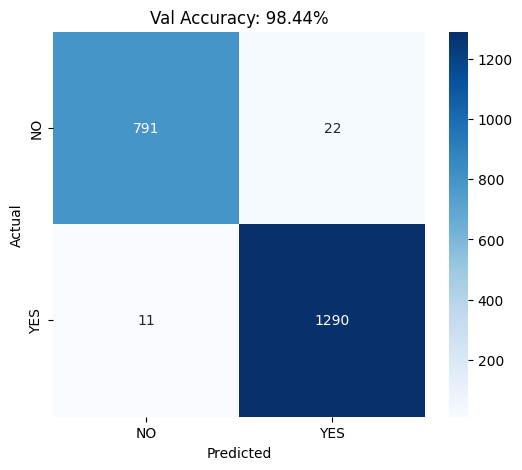

Predictions saved!


In [4]:
# FINAL TEST CODE – WORKS NO MATTER WHAT YOUR LABELS LOOK LIKE
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer



# Paths
TEST_PATH = '/kaggle/input/nlp-dataset/validation.csv'
MODEL_SAVE_DIR = '/kaggle/working/hing-roberta-sarcasm-detector-v2'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test data
df_test = pd.read_csv(TEST_PATH)
print("Val shape:", df_test.shape)
print("Unique labels in val.csv:", df_test['Label'].unique())

# Load model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model.to(device)
model.eval()

# AUTO-DETECT LABEL MAPPING (this is the real fix)
# We assume the model was trained on 2 classes → we just need to map whatever is in test.csv to 0 and 1
unique_labels = df_test['Label'].dropna().unique()
print(f"Found {len(unique_labels)} unique label(s) in val.csv: {unique_labels}")

if len(unique_labels) == 0:
    raise ValueError("val.csv has no 'Label' column or it's completely empty!")

# Create robust mapping – case-insensitive + strip spaces
label_to_id = {}
for i, label in enumerate(sorted(unique_labels, key=str.lower)):
    clean_label = str(label).strip().lower()
    if clean_label in ['yes', 'sarcastic', 'sarcasm', '1', 'positive']:
        label_to_id[label] = 1
    else:
        label_to_id[label] = 0

print("Auto-detected label mapping:")
for k, v in label_to_id.items():
    print(f"  '{k}' → {v}")

# Apply mapping
df_test['label_enc'] = df_test['Label'].map(label_to_id)

# Final safety check
if df_test['label_enc'].isnull().any():
    bad = df_test[df_test['label_enc'].isnull()]['Label'].unique()
    print(f"These labels could not be mapped and will be dropped: {bad}")
    df_test = df_test.dropna(subset=['label_enc'])

df_test['label_enc'] = df_test['label_enc'].astype(int)
print(f"Final val samples after cleaning: {len(df_test)}")

# Reverse mapping for nice output
id2label = {0: 'NO', 1: 'YES'}        # You can change display names here if you want
# Or make it match actual test labels:
# id2label = {v: k for k, v in label_to_id.items()}

target_names = ['NO', 'YES']

# Dataset & Loader
class TestDataset(torch.utils.data.Dataset):
    def __len__(self): return len(df_test)
    def __getitem__(self, idx):
        tweet = str(df_test['Tweet'].iloc[idx])
        encoding = tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(df_test['label_enc'].iloc[idx], dtype=torch.long)
        }

test_loader = DataLoader(TestDataset(), batch_size=16, shuffle=False)

# Inference
print("\nRunning inference...")
preds_list = []
labels_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

# Results
pred_labels = [id2label[p] for p in preds_list]
true_labels = [id2label[l] for l in labels_list]

print("\n" + "="*60)
print("                Val SET RESULTS")
print("="*60)
print(classification_report(true_labels, pred_labels, target_names=target_names, digits=4))

acc = accuracy_score(true_labels, pred_labels)
print(f"Val Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=target_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Val Accuracy: {acc*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save predictions
df_test['Predicted'] = pred_labels
df_test[['Tweet', 'Label', 'Predicted']].to_csv('/kaggle/working/Hing_roberta_validation.csv', index=False)
print("Predictions saved!")

Hing_RoBERTa Test

Test shape: (2109, 3)
Unique labels in test.csv: ['YES' 'NO']
Found 2 unique label(s) in test.csv: ['YES' 'NO']
Auto-detected label mapping:
  'NO' → 0
  'YES' → 1
Final test samples after cleaning: 2109

Running inference...


Testing:   0%|          | 0/132 [00:00<?, ?it/s]


                TEST SET RESULTS
              precision    recall  f1-score   support

          NO     0.9815    0.9759    0.9787       706
         YES     0.9879    0.9907    0.9893      1403

    accuracy                         0.9858      2109
   macro avg     0.9847    0.9833    0.9840      2109
weighted avg     0.9858    0.9858    0.9858      2109

Test Accuracy: 98.58%


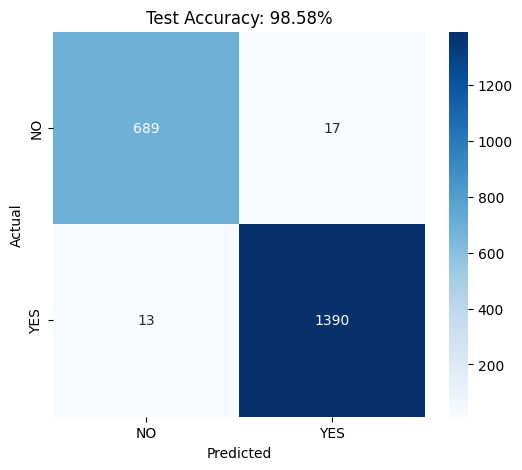

Predictions saved!


In [8]:
# FINAL TEST CODE – WORKS NO MATTER WHAT YOUR LABELS LOOK LIKE
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
TEST_PATH = '/kaggle/input/nlp-dataset/test.csv'
MODEL_SAVE_DIR = '/kaggle/working/hing-roberta-sarcasm-detector-v2'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test data
df_test = pd.read_csv(TEST_PATH)
print("Test shape:", df_test.shape)
print("Unique labels in test.csv:", df_test['Label'].unique())

# Load model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model.to(device)
model.eval()

# AUTO-DETECT LABEL MAPPING (this is the real fix)
# We assume the model was trained on 2 classes → we just need to map whatever is in test.csv to 0 and 1
unique_labels = df_test['Label'].dropna().unique()
print(f"Found {len(unique_labels)} unique label(s) in test.csv: {unique_labels}")

if len(unique_labels) == 0:
    raise ValueError("test.csv has no 'Label' column or it's completely empty!")

# Create robust mapping – case-insensitive + strip spaces
label_to_id = {}
for i, label in enumerate(sorted(unique_labels, key=str.lower)):
    clean_label = str(label).strip().lower()
    if clean_label in ['yes', 'sarcastic', 'sarcasm', '1', 'positive']:
        label_to_id[label] = 1
    else:
        label_to_id[label] = 0

print("Auto-detected label mapping:")
for k, v in label_to_id.items():
    print(f"  '{k}' → {v}")

# Apply mapping
df_test['label_enc'] = df_test['Label'].map(label_to_id)

# Final safety check
if df_test['label_enc'].isnull().any():
    bad = df_test[df_test['label_enc'].isnull()]['Label'].unique()
    print(f"These labels could not be mapped and will be dropped: {bad}")
    df_test = df_test.dropna(subset=['label_enc'])

df_test['label_enc'] = df_test['label_enc'].astype(int)
print(f"Final test samples after cleaning: {len(df_test)}")

# Reverse mapping for nice output
id2label = {0: 'NO', 1: 'YES'}        # You can change display names here if you want
# Or make it match actual test labels:
# id2label = {v: k for k, v in label_to_id.items()}

target_names = ['NO', 'YES']

# Dataset & Loader
class TestDataset(torch.utils.data.Dataset):
    def __len__(self): return len(df_test)
    def __getitem__(self, idx):
        tweet = str(df_test['Tweet'].iloc[idx])
        encoding = tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(df_test['label_enc'].iloc[idx], dtype=torch.long)
        }

test_loader = DataLoader(TestDataset(), batch_size=16, shuffle=False)

# Inference
print("\nRunning inference...")
preds_list = []
labels_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

# Results
pred_labels = [id2label[p] for p in preds_list]
true_labels = [id2label[l] for l in labels_list]

print("\n" + "="*60)
print("                TEST SET RESULTS")
print("="*60)
print(classification_report(true_labels, pred_labels, target_names=target_names, digits=4))

acc = accuracy_score(true_labels, pred_labels)
print(f"Test Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=target_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Test Accuracy: {acc*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save predictions
df_test['Predicted'] = pred_labels
df_test[['Tweet', 'Label', 'Predicted']].to_csv('/kaggle/working/test_predictions.csv', index=False)
print("Predictions saved!")

Hing_mBERT Train

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW
from tqdm import tqdm
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import os
from tqdm.notebook import tqdm   # ← This is the key fix for Kaggle!

# ==========================================
# 1. CONFIGURATION
# ==========================================
TRAIN_PATH = '/kaggle/input/nlp-dataset/train.csv'
VAL_PATH   = '/kaggle/input/nlp-dataset/validation.csv'

MODEL_NAME = 'l3cube-pune/hing-mbert'        # Great for Hinglish
MAX_LEN = 128
BATCH_SIZE = 16
EPOCHS = 4
LEARNING_RATE = 2e-5
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Unique model save name
SAVE_DIR = '/kaggle/working/hing-mbert-sarcasm-detector-v2'

print(f"Using device: {DEVICE}")
print(f"Model will be saved as: {SAVE_DIR}")

# ==========================================
# 2. DATA LOADING
# ==========================================
print("Loading train and validation CSVs...")
df_train = pd.read_csv(TRAIN_PATH)
df_val   = pd.read_csv(VAL_PATH)

# Ensure column names are correct (adjust if different)
# Expected: 'Tweet' (text) and 'Label' (Sarcastic/Non-Sarcastic or 0/1)
print("Train columns:", df_train.columns.tolist())
print("Val columns:  ", df_val.columns.tolist())

# Encode labels
le = LabelEncoder()
# Fit on combined labels to ensure same mapping
all_labels = pd.concat([df_train['Label'], df_val['Label']], axis=0)
le.fit(all_labels)

df_train['label_enc'] = le.transform(df_train['Label'])
df_val['label_enc']   = le.transform(df_val['Label'])

print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

# ==========================================
# 3. DATASET CLASS
# ==========================================
class SarcasmDataset(Dataset):
    def __init__(self, tweets, labels, tokenizer, max_len):
        self.tweets = tweets
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.tweets)

    def __getitem__(self, idx):
        tweet = str(self.tweets[idx])
        label = self.labels[idx]

        encoding = self.tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

# ==========================================
# 4. DATA LOADERS
# ==========================================
def create_data_loader(df, tokenizer, max_len, batch_size):
    dataset = SarcasmDataset(
        tweets=df['Tweet'].to_numpy(),
        labels=df['label_enc'].to_numpy(),
        tokenizer=tokenizer,
        max_len=max_len
    )
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

train_loader = create_data_loader(df_train, tokenizer, MAX_LEN, BATCH_SIZE)
val_loader   = create_data_loader(df_val,   tokenizer, MAX_LEN, BATCH_SIZE)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}")

# ==========================================
# 5. MODEL SETUP
# ==========================================
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(le.classes_)
)
model.to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LEARNING_RATE)
total_steps = len(train_loader) * EPOCHS
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=0,
    num_training_steps=total_steps
)

# ==========================================
# 6. TRAINING & EVALUATION FUNCTIONS (FIXED FOR KAGGLE)
# ==========================================


def train_epoch(model, loader, optimizer, device, scheduler):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    # One clean progress bar — no new lines per step
    pbar = tqdm(total=len(loader), desc=f"Training Epoch", leave=True)
    
    for batch in loader:
        optimizer.zero_grad()

        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()

        _, preds = torch.max(outputs.logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)
        total_loss += loss.item()

        # Update the SAME bar smoothly
        pbar.update(1)
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc' : f'{correct/total:.4f}'
        })

    pbar.close()
    return correct / total, total_loss / len(loader)


def evaluate(model, loader, device):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []

    pbar = tqdm(total=len(loader), desc="Evaluating", leave=True)

    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels = batch['labels'].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
            loss = outputs.loss
            logits = outputs.logits

            _, preds = torch.max(logits, dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            correct += (preds == labels).sum().item()
            total += labels.size(0)
            total_loss += loss.item()

            pbar.update(1)
            pbar.set_postfix({
                'loss': f'{loss.item():.4f}',
                'acc' : f'{correct/total:.4f}'
            })

    pbar.close()
    return correct / total, total_loss / len(loader), all_preds, all_labels


# ==========================================
# 7. TRAINING LOOP
# ==========================================
print("\n" + "="*50)
print("STARTING TRAINING")
print("="*50)

for epoch in range(1, EPOCHS + 1):
    print(f"\nEpoch {epoch}/{EPOCHS}")
    train_acc, train_loss = train_epoch(model, train_loader, optimizer, DEVICE, scheduler)
    print(f"→ Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")

    val_acc, val_loss, _, _ = evaluate(model, val_loader, DEVICE)
    print(f"→ Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")

# ==========================================
# 8. FINAL EVALUATION & REPORT
# ==========================================
print("\nGenerating final report on validation set...")
val_acc, val_loss, y_pred, y_true = evaluate(model, val_loader, DEVICE)

print("\n" + classification_report(y_true, y_pred, target_names=le.classes_))
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f'HingmBERT Sarcasm Detector (Val Acc: {val_acc*100:.2f}%)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# ==========================================
# 9. SAVE MODEL WITH UNIQUE NAME
# ==========================================
os.makedirs(SAVE_DIR, exist_ok=True)

model.save_pretrained(SAVE_DIR)
tokenizer.save_pretrained(SAVE_DIR)

print(f"\nModel and tokenizer successfully saved to:")
print(f"→ {SAVE_DIR}")

print("\nTo load later:")
print(f"""model = AutoModelForSequenceClassification.from_pretrained("{SAVE_DIR}")""")
print(f"""tokenizer = AutoTokenizer.from_pretrained("{SAVE_DIR}")""")

Hing_mBERT validation

Val shape: (2114, 3)
Unique labels in val.csv: ['YES' 'NO']
Found 2 unique label(s) in val.csv: ['YES' 'NO']
Auto-detected label mapping:
  'NO' → 0
  'YES' → 1
Final val samples after cleaning: 2114

Running inference...


Testing:   0%|          | 0/133 [00:00<?, ?it/s]


                Val SET RESULTS
              precision    recall  f1-score   support

          NO     0.9899    0.9656    0.9776       813
         YES     0.9788    0.9939    0.9863      1301

    accuracy                         0.9830      2114
   macro avg     0.9844    0.9797    0.9819      2114
weighted avg     0.9831    0.9830    0.9829      2114

Val Accuracy: 98.30%


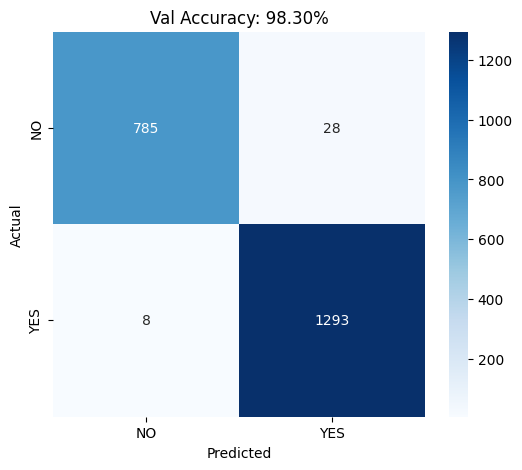

Predictions saved!


In [5]:
# FINAL TEST CODE – WORKS NO MATTER WHAT YOUR LABELS LOOK LIKE
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
from transformers import AutoModelForSequenceClassification, AutoTokenizer



# Paths
TEST_PATH = '/kaggle/input/nlp-dataset/validation.csv'
MODEL_SAVE_DIR = '/kaggle/working/hing-mbert-sarcasm-detector-v2'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test data
df_test = pd.read_csv(TEST_PATH)
print("Val shape:", df_test.shape)
print("Unique labels in val.csv:", df_test['Label'].unique())

# Load model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model.to(device)
model.eval()

# AUTO-DETECT LABEL MAPPING (this is the real fix)
# We assume the model was trained on 2 classes → we just need to map whatever is in test.csv to 0 and 1
unique_labels = df_test['Label'].dropna().unique()
print(f"Found {len(unique_labels)} unique label(s) in val.csv: {unique_labels}")

if len(unique_labels) == 0:
    raise ValueError("val.csv has no 'Label' column or it's completely empty!")

# Create robust mapping – case-insensitive + strip spaces
label_to_id = {}
for i, label in enumerate(sorted(unique_labels, key=str.lower)):
    clean_label = str(label).strip().lower()
    if clean_label in ['yes', 'sarcastic', 'sarcasm', '1', 'positive']:
        label_to_id[label] = 1
    else:
        label_to_id[label] = 0

print("Auto-detected label mapping:")
for k, v in label_to_id.items():
    print(f"  '{k}' → {v}")

# Apply mapping
df_test['label_enc'] = df_test['Label'].map(label_to_id)

# Final safety check
if df_test['label_enc'].isnull().any():
    bad = df_test[df_test['label_enc'].isnull()]['Label'].unique()
    print(f"These labels could not be mapped and will be dropped: {bad}")
    df_test = df_test.dropna(subset=['label_enc'])

df_test['label_enc'] = df_test['label_enc'].astype(int)
print(f"Final val samples after cleaning: {len(df_test)}")

# Reverse mapping for nice output
id2label = {0: 'NO', 1: 'YES'}        # You can change display names here if you want
# Or make it match actual test labels:
# id2label = {v: k for k, v in label_to_id.items()}

target_names = ['NO', 'YES']

# Dataset & Loader
class TestDataset(torch.utils.data.Dataset):
    def __len__(self): return len(df_test)
    def __getitem__(self, idx):
        tweet = str(df_test['Tweet'].iloc[idx])
        encoding = tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(df_test['label_enc'].iloc[idx], dtype=torch.long)
        }

test_loader = DataLoader(TestDataset(), batch_size=16, shuffle=False)

# Inference
print("\nRunning inference...")
preds_list = []
labels_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

# Results
pred_labels = [id2label[p] for p in preds_list]
true_labels = [id2label[l] for l in labels_list]

print("\n" + "="*60)
print("                Val SET RESULTS")
print("="*60)
print(classification_report(true_labels, pred_labels, target_names=target_names, digits=4))

acc = accuracy_score(true_labels, pred_labels)
print(f"Val Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=target_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Val Accuracy: {acc*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save predictions
df_test['Predicted'] = pred_labels
df_test[['Tweet', 'Label', 'Predicted']].to_csv('/kaggle/working/Hing_mbert_validation.csv', index=False)
print("Predictions saved!")

Hing_mBERT Test

Test shape: (2109, 3)
Unique labels in test.csv: ['YES' 'NO']
Found 2 unique label(s) in test.csv: ['YES' 'NO']
Auto-detected label mapping:
  'NO' → 0
  'YES' → 1
Final test samples after cleaning: 2109

Running inference...


Testing:   0%|          | 0/132 [00:00<?, ?it/s]


                TEST SET RESULTS
              precision    recall  f1-score   support

          NO     0.9815    0.9773    0.9794       706
         YES     0.9886    0.9907    0.9897      1403

    accuracy                         0.9862      2109
   macro avg     0.9851    0.9840    0.9845      2109
weighted avg     0.9862    0.9862    0.9862      2109

Test Accuracy: 98.62%


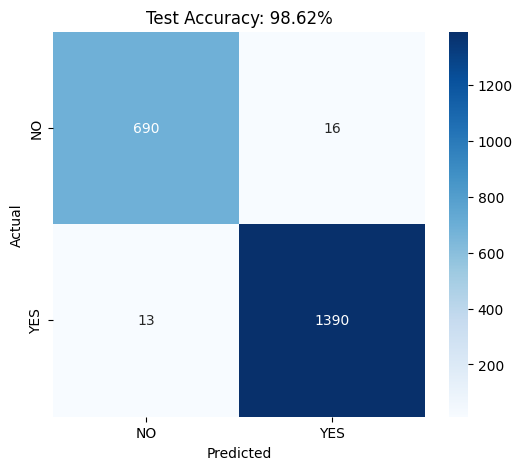

Predictions saved!


In [9]:
# FINAL TEST CODE – WORKS NO MATTER WHAT YOUR LABELS LOOK LIKE
import pandas as pd
import torch
from torch.utils.data import DataLoader
from tqdm.notebook import tqdm
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Paths
TEST_PATH = '/kaggle/input/nlp-dataset/test.csv'
MODEL_SAVE_DIR = '/kaggle/working/hing-mbert-sarcasm-detector-v2'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Load test data
df_test = pd.read_csv(TEST_PATH)
print("Test shape:", df_test.shape)
print("Unique labels in test.csv:", df_test['Label'].unique())

# Load model & tokenizer
model = AutoModelForSequenceClassification.from_pretrained(MODEL_SAVE_DIR)
tokenizer = AutoTokenizer.from_pretrained(MODEL_SAVE_DIR)
model.to(device)
model.eval()

# AUTO-DETECT LABEL MAPPING (this is the real fix)
# We assume the model was trained on 2 classes → we just need to map whatever is in test.csv to 0 and 1
unique_labels = df_test['Label'].dropna().unique()
print(f"Found {len(unique_labels)} unique label(s) in test.csv: {unique_labels}")

if len(unique_labels) == 0:
    raise ValueError("test.csv has no 'Label' column or it's completely empty!")

# Create robust mapping – case-insensitive + strip spaces
label_to_id = {}
for i, label in enumerate(sorted(unique_labels, key=str.lower)):
    clean_label = str(label).strip().lower()
    if clean_label in ['yes', 'sarcastic', 'sarcasm', '1', 'positive']:
        label_to_id[label] = 1
    else:
        label_to_id[label] = 0

print("Auto-detected label mapping:")
for k, v in label_to_id.items():
    print(f"  '{k}' → {v}")

# Apply mapping
df_test['label_enc'] = df_test['Label'].map(label_to_id)

# Final safety check
if df_test['label_enc'].isnull().any():
    bad = df_test[df_test['label_enc'].isnull()]['Label'].unique()
    print(f"These labels could not be mapped and will be dropped: {bad}")
    df_test = df_test.dropna(subset=['label_enc'])

df_test['label_enc'] = df_test['label_enc'].astype(int)
print(f"Final test samples after cleaning: {len(df_test)}")

# Reverse mapping for nice output
id2label = {0: 'NO', 1: 'YES'}        # You can change display names here if you want
# Or make it match actual test labels:
# id2label = {v: k for k, v in label_to_id.items()}

target_names = ['NO', 'YES']

# Dataset & Loader
class TestDataset(torch.utils.data.Dataset):
    def __len__(self): return len(df_test)
    def __getitem__(self, idx):
        tweet = str(df_test['Tweet'].iloc[idx])
        encoding = tokenizer.encode_plus(
            tweet,
            add_special_tokens=True,
            max_length=128,
            padding='max_length',
            truncation=True,
            return_attention_mask=True,
            return_tensors='pt',
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(df_test['label_enc'].iloc[idx], dtype=torch.long)
        }

test_loader = DataLoader(TestDataset(), batch_size=16, shuffle=False)

# Inference
print("\nRunning inference...")
preds_list = []
labels_list = []

with torch.no_grad():
    for batch in tqdm(test_loader, desc="Testing"):
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(input_ids, attention_mask=attention_mask)
        preds = torch.argmax(outputs.logits, dim=1)

        preds_list.extend(preds.cpu().numpy())
        labels_list.extend(labels.cpu().numpy())

# Results
pred_labels = [id2label[p] for p in preds_list]
true_labels = [id2label[l] for l in labels_list]

print("\n" + "="*60)
print("                TEST SET RESULTS")
print("="*60)
print(classification_report(true_labels, pred_labels, target_names=target_names, digits=4))

acc = accuracy_score(true_labels, pred_labels)
print(f"Test Accuracy: {acc*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(true_labels, pred_labels, labels=target_names)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.title(f'Test Accuracy: {acc*100:.2f}%')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Save predictions
df_test['Predicted'] = pred_labels
df_test[['Tweet', 'Label', 'Predicted']].to_csv('/kaggle/working/test_predictions.csv', index=False)
print("Predictions saved!")